In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

In [ ]:
!kaggle datasets download kmader/food41

Dataset URL: https://www.kaggle.com/datasets/kmader/food41
License(s): copyright-authors
100% 5.30G/5.30G [00:44<00:00, 129MB/s]



In [ ]:
!unzip /content/food41.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/tacos/1026681.jpg  
  inflating: images/tacos/1030289.jpg  
  inflating: images/tacos/1033196.jpg  
  inflating: images/tacos/1036030.jpg  
  inflating: images/tacos/1042175.jpg  
  inflating: images/tacos/1044043.jpg  
  inflating: images/tacos/1058697.jpg  
  inflating: images/tacos/1059239.jpg  
  inflating: images/tacos/1059326.jpg  
  inflating: images/tacos/1066762.jpg  
  inflating: images/tacos/1070967.jpg  
  inflating: images/tacos/1073468.jpg  
  inflating: images/tacos/1075296.jpg  
  inflating: images/tacos/1085243.jpg  
  inflating: images/tacos/108529.jpg  
  inflating: images/tacos/1086014.jpg  
  inflating: images/tacos/108945.jpg  
  inflating: images/tacos/1089575.jpg  
  inflating: images/tacos/1091159.jpg  
  inflating: images/tacos/1101369.jpg  
  inflating: images/tacos/1109058.jpg  
  inflating: images/tacos/1109744.jpg  
  inflating: images/tacos/1119371.jpg  
  inflating: images/tacos/11237

In [ ]:
import os

food_101_data = "/content/images"
food_101_classes = os.listdir(food_101_data)

In [ ]:
food_101_classes

['grilled_cheese_sandwich',
 'crab_cakes',
 'bread_pudding',
 'omelette',
 'scallops',
 'french_fries',
 'caesar_salad',
 'chicken_quesadilla',
 'spring_rolls',
 'takoyaki',
 'strawberry_shortcake',
 'filet_mignon',
 'risotto',
 'shrimp_and_grits',
 'guacamole',
 'ice_cream',
 'pho',
 'churros',
 'chicken_wings',
 'frozen_yogurt',
 'bruschetta',
 'club_sandwich',
 'gyoza',
 'macaroni_and_cheese',
 'carrot_cake',
 'steak',
 'miso_soup',
 'apple_pie',
 'baby_back_ribs',
 'dumplings',
 'hot_and_sour_soup',
 'spaghetti_bolognese',
 'hot_dog',
 'eggs_benedict',
 'garlic_bread',
 'pad_thai',
 'lobster_roll_sandwich',
 'french_onion_soup',
 'beignets',
 'oysters',
 'chocolate_mousse',
 'poutine',
 'pancakes',
 'peking_duck',
 'fried_calamari',
 'macarons',
 'sushi',
 'creme_brulee',
 'spaghetti_carbonara',
 'chocolate_cake',
 'huevos_rancheros',
 'onion_rings',
 'mussels',
 'breakfast_burrito',
 'red_velvet_cake',
 'waffles',
 'hummus',
 'ceviche',
 'hamburger',
 'nachos',
 'foie_gras',
 'fal

In [ ]:
target_size = (64, 64)

In [ ]:
!pip install torchvision

In [ ]:
from torchvision import transforms, datasets

In [ ]:
# Transformasiya
transform  = transforms.Compose([
    transforms.Resize(target_size),
    transforms.ToTensor(), # (3, 64, 64)
    transforms.Normalize((0.5, ), (0.5, )) # [0, 1] -> [-1, 1]
])

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [ ]:
device

'cuda'

In [ ]:
# temp data (ilkin dataset) indeks-ləri və class-ları müəyyənləşdirmək üçün yaradırıq
temp_data = datasets.ImageFolder(root=food_101_data)

In [ ]:
pizza_idx = temp_data.class_to_idx['pizza'] # pizza -> 0
sushi_idx = temp_data.class_to_idx['sushi'] # sushi -> 1

In [ ]:
indices_A = [i for i, (img, label) in enumerate(temp_data.samples) if label not in [pizza_idx, sushi_idx]] # -> (2, ('image_path', 'image_class_indeks'))

In [ ]:
unique_A = sorted(list(set(temp_data.samples[i][1] for i in indices_A)))
map_A = {old: new for new, old in enumerate(unique_A)}

In [ ]:
full_data_A = datasets.ImageFolder(root=food_101_data, transform=transform, target_transform=lambda y: map_A[y] if y in map_A else y)

In [ ]:
dataset_A = Subset(full_data_A, indices_A)

In [ ]:
# indices_B -> 2000 images
# indices_A -> 99,000 images

In [ ]:
indices_B = [i for i, (img, label) in enumerate(temp_data.samples) if label in [pizza_idx, sushi_idx]] # -> (0, ('image_path', 'image_class_indeks'))

In [ ]:
map_B = {pizza_idx: 0, sushi_idx: 1}

In [ ]:
full_data_B = datasets.ImageFolder(root=food_101_data, transform=transform, target_transform=lambda y: map_B[y] if y in map_B else y)

In [ ]:
dataset_B = Subset(full_data_B, indices_B)

In [ ]:
train_A, valid_A, test_A = random_split(dataset_A, [0.8, 0.1, 0.1])
train_loader_A = DataLoader(train_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_A, batch_size=32)
test_loader_A = DataLoader(test_A, batch_size=32)

In [ ]:
train_B, valid_B, test_B = random_split(dataset_B, [0.7, 0.15, 0.15])
train_loader_B = DataLoader(train_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_B, batch_size=32)
test_loader_B = DataLoader(test_B, batch_size=32)

In [ ]:
# (sqrt(6 / input_features)) ->(fan_in)

In [ ]:
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

In [ ]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred[:, 1], y_batch)
    return metric.compute()

In [ ]:
def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        metric.reset()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred[:, 1], y_batch)

        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch+1}: Loss {history['train_losses'][-1]:.4f}, Train Acc {history['train_metrics'][-1]:.4f}, Val Acc {history['valid_metrics'][-1]:.4f}")
    return history

In [ ]:
model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 64 * 64, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 99)
).to(device)
model_A.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=99, bias=True)
)

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.7 MB/s eta 0:00:00


In [ ]:
import torchmetrics

In [ ]:
optimizer_A = torch.optim.SGD(model_A.parameters(), lr=0.005)
loss_A = nn.CrossEntropyLoss() # label -> output[label]
acc_A = torchmetrics.Accuracy(task="multiclass", num_classes=99).to(device)
history_A = train(model_A, optimizer_A, loss_A, acc_A, train_loader_A, valid_loader_A, n_epochs=5)

Epoch 1: Loss 4.5655, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 4.4232, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 4.3079, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 4.2227, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 4.1587, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 64 * 64, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 2)
).to(device)
model_B.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=2, bias=True)
)

In [ ]:
optimizer_B = torch.optim.SGD(model_B.parameters(), lr=0.005)
loss_B = nn.CrossEntropyLoss()
acc_B = torchmetrics.Accuracy(task="binary", num_classes=2).to(device)
history_B = train(model_B, optimizer_B, loss_B, acc_B, train_loader_B, valid_loader_B, n_epochs=5)

Epoch 1: Loss 0.6703, Train Acc 0.5807, Val Acc 0.6433
Epoch 2: Loss 0.5384, Train Acc 0.6836, Val Acc 0.6267
Epoch 3: Loss 0.4569, Train Acc 0.7350, Val Acc 0.6033
Epoch 4: Loss 0.4000, Train Acc 0.7736, Val Acc 0.6233
Epoch 5: Loss 0.3424, Train Acc 0.8014, Val Acc 0.5967


In [ ]:
import copy
reused_layers = copy.deepcopy(model_A[:-1])
model_B_on_A = nn.Sequential(
    *reused_layers,
    nn.Linear(100, 2)
).to(device)

In [ ]:
for param in model_B_on_A[:-1].parameters():
    param.requires_grad = False

In [ ]:
optimizer_TL = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
history_TL = train(model_B_on_A, optimizer_TL, loss_B, acc_B, train_loader_B, valid_loader_B, n_epochs=5)

Epoch 1: Loss 0.7201, Train Acc 0.4286, Val Acc 0.4967
Epoch 2: Loss 0.6597, Train Acc 0.5207, Val Acc 0.5500
Epoch 3: Loss 0.6431, Train Acc 0.5714, Val Acc 0.5667
Epoch 4: Loss 0.6387, Train Acc 0.5900, Val Acc 0.6033
Epoch 5: Loss 0.6352, Train Acc 0.6050, Val Acc 0.6067


In [ ]:
for param in model_B_on_A[2:].parameters():
    param.requires_grad = True

In [ ]:
def build_model():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3 * 64 * 64, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 10)
    ).to(device)
    model.apply(use_he_init)
    return model

In [ ]:
def test_optimizer(opt_class, opt_params):
    m = build_model()
    opt = opt_class(m.parameters(), **opt_params)
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train(m, opt, nn.CrossEntropyLoss(), metric,
                    train_loader_B, valid_loader_B, n_epochs=10)
    test_loader = DataLoader(test_B, batch_size=32)
    acc = evaluate_tm(m, test_loader, metric)
    return history, acc

In [ ]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
history_sgd, acc_sgd = test_optimizer(torch.optim.SGD,  {"lr": 0.05})

Epoch 1: Loss 1.1273, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 0.6601, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 0.5804, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 0.5325, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.4866, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.4031, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.3222, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.2665, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.2395, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.2092, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, lr=0.05)
history_momentum, acc_momentum = test_optimizer(torch.optim.SGD, {"lr": 0.05, "momentum": 0.9})

Epoch 1: Loss 1.9997, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 2.0914, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 0.7576, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 0.7208, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.7141, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.7071, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.7016, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.7015, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.6964, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.6958, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(),
                            momentum=0.9, nesterov=True, lr=0.05)
history_nesterov, acc_nesterov = test_optimizer(torch.optim.SGD, {"lr": 0.05, "momentum": 0.9, "nesterov": True})

Epoch 1: Loss 11.7445, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 1.4332, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 0.7310, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 0.7176, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.7121, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.7086, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.7052, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.7046, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.7029, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.7008, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.05)
history_adagrad, acc_adagrad = test_optimizer(torch.optim.Adagrad, {"lr": 0.05})

Epoch 1: Loss 42.5841, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 1.1124, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 0.5710, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 0.4857, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.3857, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.3292, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.2827, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.2363, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.2128, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.1837, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), alpha=0.9, lr=0.05)
history_rmsprop, acc_rmsprop = test_optimizer(torch.optim.RMSprop, {"lr": 0.05, "alpha": 0.9})

Epoch 1: Loss 481.8341, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 7.2720, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 4.1191, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 3.1007, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.8100, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.7044, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.7848, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.9541, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.7483, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.6932, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_adam, acc_adam = test_optimizer(torch.optim.Adam, {"lr": 0.05, "betas": (0.9, 0.999)})

Epoch 1: Loss 45.8600, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 1.2747, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 1.0683, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 1.0788, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.8743, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.7525, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.7703, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.7567, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 1.2199, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.9517, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.Adamax(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_adamax, acc_adamax = test_optimizer(torch.optim.Adamax, {"lr": 0.05, "betas": (0.9, 0.999)})

Epoch 1: Loss 33.2345, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 1.9053, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 0.7854, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 0.8760, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.5906, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.5469, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.5350, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.5117, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.4858, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.4816, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.NAdam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_nadam, acc_nadam = test_optimizer(torch.optim.NAdam, {"lr": 0.05, "betas": (0.9, 0.999)})

Epoch 1: Loss 40.8187, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 2.6178, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 1.7326, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 0.7900, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.7508, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.6460, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.6168, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.6300, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.6896, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.6135, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.999),
                              weight_decay=1e-5, lr=0.05)
history_adamw, acc_adamw = test_optimizer(torch.optim.AdamW, {"lr": 0.05, "betas": (0.9, 0.999), "weight_decay": 1e-5})

Epoch 1: Loss 43.3294, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 1.2451, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 0.8534, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 1.0856, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 1.5316, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.7155, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.7064, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.6753, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.6824, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.6850, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
model = build_model()
optimizer = torch.optim.AdamW(model.parameters(),
                              weight_decay=1e-5, lr=0.05)
history_muon, acc_muon = test_optimizer(torch.optim.AdamW, {"lr": 0.05, "weight_decay": 1e-5})

Epoch 1: Loss 60.2419, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 2.8029, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 0.8601, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 0.7497, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.7162, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.7250, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.7674, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 1.0712, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.7595, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.6728, Train Acc 0.0000, Val Acc 0.0000


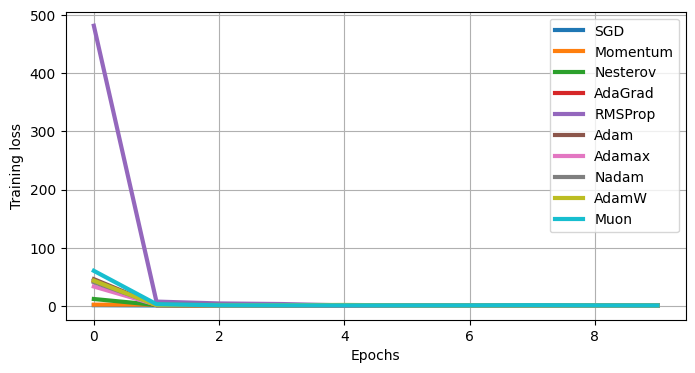

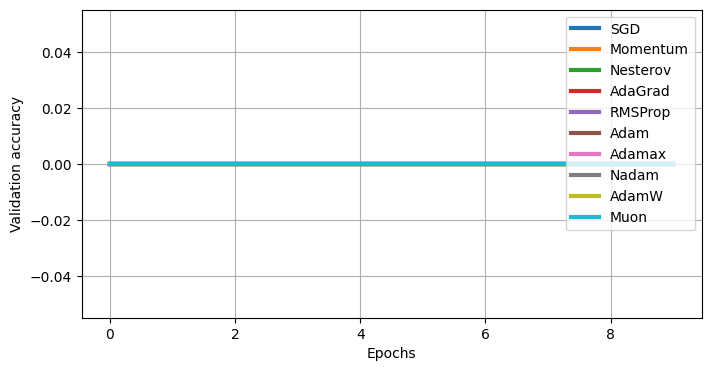

In [ ]:
for plot in ("train_losses", "valid_metrics"):
    plt.figure(figsize=(8, 4))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW Muon"
    for history, opt_name in zip(
        (history_sgd, history_momentum, history_nesterov, history_adagrad,
         history_rmsprop, history_adam, history_adamax, history_nadam,
         history_adamw, history_muon), opt_names.split()):
        plt.plot(history[plot], label=opt_name, linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"train_losses": "Training loss", "valid_metrics": "Validation accuracy"}[plot])
    plt.legend(loc="upper right")
    plt.show()

In [ ]:
# Learning Rate Scheduler

# Scheduler testləri üçün Dataset A-dan 10-class subset götürürük
# (ilk 10 class, sürətli test üçün)
SCHEDULER_NUM_CLASSES = 10

In [ ]:
# Dataset A-dan yalnız ilk 10 class-ı seçirik
all_labels_A = [temp_data.samples[i][1] for i in indices_A]
first_10_old = sorted(unique_A)[:SCHEDULER_NUM_CLASSES]
first_10_new = [map_A[l] for l in first_10_old]

In [ ]:
scheduler_indices = [
    idx for idx, i in enumerate(indices_A)
    if map_A[temp_data.samples[i][1]] in first_10_new
]

In [ ]:
scheduler_dataset = Subset(full_data_A, [indices_A[i] for i in scheduler_indices])

In [ ]:
train_sched, valid_sched, test_sched = random_split(
    scheduler_dataset, [0.8, 0.1, 0.1]
)

In [ ]:
def build_model(num_classes=SCHEDULER_NUM_CLASSES):
    """
    Scheduler testləri üçün sadə MLP.
    num_classes parametri ilə fərqli tapşırıqlara uyğunlaşır.
    """
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3 * 64 * 64, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    ).to(device)
    model.apply(use_he_init)
    return model

In [ ]:
# Training with scheduler
def train_with_scheduler(model, optimizer, loss_fn, metric,
                         train_loader, valid_loader, n_epochs, scheduler):
    """
    Universal training loop — ReduceLROnPlateau da daxil olmaqla
    bütün scheduler tipləri ilə işləyir.
    """
    history = {
        "train_losses": [],
        "train_metrics": [],
        "valid_metrics": [],
        "learning_rates": []   # LR tarixçəsi — qrafik üçün
    }
    for epoch in range(n_epochs):
        model.train()
        losses = []
        metric.reset()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        # Scheduler addımı
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_metric)
            current_lr = optimizer.param_groups[0]['lr']
        else:
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]
        history["learning_rates"].append(current_lr)
        print(
            f"Epoch {epoch+1}/{n_epochs} | "
            f"Loss: {history['train_losses'][-1]:.4f} | "
            f"Train Acc: {history['train_metrics'][-1]:.4f} | "
            f"Val Acc: {val_metric:.4f} | "
            f"LR: {current_lr:.6f}"
        )
    return history

In [ ]:
def test_scheduler(scheduler_name, scheduler_factory, n_epochs=10):
    """
    Hər scheduler üçün təmiz model və optimizer yaradır, öyrədir,
    history + test accuracy qaytarır.
    scheduler_factory: (model, optimizer) -> scheduler
    """
    model = build_model()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
    scheduler = scheduler_factory(model, optimizer)
    train_loader = DataLoader(train_sched, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_sched, batch_size=32)
    test_loader  = DataLoader(test_sched,  batch_size=32)
    loss_fn = nn.CrossEntropyLoss()
    metric  = torchmetrics.Accuracy(
        task="multiclass", num_classes=SCHEDULER_NUM_CLASSES
    ).to(device)
    print(f"\n{'='*55}")
    print(f"  Scheduler: {scheduler_name}")
    print(f"{'='*55}")
    history = train_with_scheduler(
        model, optimizer, loss_fn, metric,
        train_loader, valid_loader, n_epochs, scheduler
    )
    test_acc = evaluate_tm(model, test_loader, metric).item()
    print(f"  → Test Accuracy: {test_acc:.4f}")
    return history, test_acc

In [ ]:
# Warmup və ReduceLROnPlateau birlikdə qurulur
def train_with_warmup(model, optimizer, loss_fn, metric,
                      train_loader, valid_loader, n_epochs,
                      warmup_scheduler, main_scheduler,
                      warmup_epochs=3):
    """
    İlk `warmup_epochs` epoch: warmup_scheduler aktiv.
    Sonra: main_scheduler (ReduceLROnPlateau) aktiv.
    """
    history = {
        "train_losses": [],
        "train_metrics": [],
        "valid_metrics": [],
        "learning_rates": []
    }
    for epoch in range(n_epochs):
        model.train()
        losses = []
        metric.reset()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)

        if epoch < warmup_epochs:
            warmup_scheduler.step()
            current_lr = warmup_scheduler.get_last_lr()[0]
            phase = "warmup"
        else:
            main_scheduler.step(val_metric)
            current_lr = optimizer.param_groups[0]['lr']
            phase = "ReduceLROnPlateau"
        history["learning_rates"].append(current_lr)
        print(
            f"Epoch {epoch+1}/{n_epochs} [{phase}] | "
            f"Loss: {history['train_losses'][-1]:.4f} | "
            f"Train Acc: {history['train_metrics'][-1]:.4f} | "
            f"Val Acc: {val_metric:.4f} | "
            f"LR: {current_lr:.6f}"
        )
    return history

In [ ]:
def test_warmup_scheduler(n_epochs=10, warmup_epochs=3):
    model = build_model()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
    )
    main_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.1
    )
    train_loader = DataLoader(train_sched, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_sched, batch_size=32)
    test_loader  = DataLoader(test_sched,  batch_size=32)
    loss_fn = nn.CrossEntropyLoss()
    metric  = torchmetrics.Accuracy(
        task="multiclass", num_classes=SCHEDULER_NUM_CLASSES
    ).to(device)
    print(f"\n{'='*55}")
    print(f"  Scheduler: Warmup (LinearLR) and ReduceLROnPlateau")
    print(f"{'='*55}")
    history = train_with_warmup(
        model, optimizer, loss_fn, metric,
        train_loader, valid_loader, n_epochs,
        warmup_scheduler, main_scheduler, warmup_epochs
    )
    test_acc = evaluate_tm(model, test_loader, metric).item()
    print(f"  → Test Accuracy: {test_acc:.4f}")
    return history, test_acc

In [ ]:
# Scheduling testləri
N_EPOCHS = 10

# Exponential Learning Rate
history_exp, acc_exp = test_scheduler("ExponentialLR (gamma=0.9)", lambda m, opt: torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9))


  Scheduler: ExponentialLR (gamma=0.9)
Epoch 1/10 | Loss: 2.1419 | Train Acc: 0.2428 | Val Acc: 0.0000 | LR: 0.045000
Epoch 2/10 | Loss: 1.8606 | Train Acc: 0.3520 | Val Acc: 0.0000 | LR: 0.040500
Epoch 3/10 | Loss: 1.6808 | Train Acc: 0.4104 | Val Acc: 0.0000 | LR: 0.036450
Epoch 4/10 | Loss: 1.5086 | Train Acc: 0.4821 | Val Acc: 0.0000 | LR: 0.032805
Epoch 5/10 | Loss: 1.3231 | Train Acc: 0.5499 | Val Acc: 0.0000 | LR: 0.029525
Epoch 6/10 | Loss: 1.1420 | Train Acc: 0.6135 | Val Acc: 0.0000 | LR: 0.026572
Epoch 7/10 | Loss: 0.9615 | Train Acc: 0.6846 | Val Acc: 0.0000 | LR: 0.023915
Epoch 8/10 | Loss: 0.7959 | Train Acc: 0.7494 | Val Acc: 0.0000 | LR: 0.021523
Epoch 9/10 | Loss: 0.6427 | Train Acc: 0.8123 | Val Acc: 0.0000 | LR: 0.019371
Epoch 10/10 | Loss: 0.5088 | Train Acc: 0.8576 | Val Acc: 0.0000 | LR: 0.017434
  → Test Accuracy: 0.0000


In [ ]:
# ReduceLROnPlateau
history_perf, acc_perf = test_scheduler("ReduceLROnPlateau (patience=2, factor=0.1)", lambda m, opt: torch.optim.lr_scheduler.ReduceLROnPlateau(
                                         opt, mode="max", patience=2, factor=0.1))


  Scheduler: ReduceLROnPlateau (patience=2, factor=0.1)
Epoch 1/10 | Loss: 2.1430 | Train Acc: 0.2434 | Val Acc: 0.0000 | LR: 0.050000
Epoch 2/10 | Loss: 1.8816 | Train Acc: 0.3372 | Val Acc: 0.0000 | LR: 0.050000
Epoch 3/10 | Loss: 1.7260 | Train Acc: 0.3964 | Val Acc: 0.0000 | LR: 0.050000
Epoch 4/10 | Loss: 1.5653 | Train Acc: 0.4549 | Val Acc: 0.0000 | LR: 0.005000
Epoch 5/10 | Loss: 1.2397 | Train Acc: 0.5957 | Val Acc: 0.0000 | LR: 0.005000
Epoch 6/10 | Loss: 1.1289 | Train Acc: 0.6429 | Val Acc: 0.0000 | LR: 0.005000
Epoch 7/10 | Loss: 1.0666 | Train Acc: 0.6634 | Val Acc: 0.0000 | LR: 0.000500
Epoch 8/10 | Loss: 0.9985 | Train Acc: 0.6917 | Val Acc: 0.0000 | LR: 0.000500
Epoch 9/10 | Loss: 0.9901 | Train Acc: 0.6954 | Val Acc: 0.0000 | LR: 0.000500
Epoch 10/10 | Loss: 0.9835 | Train Acc: 0.6976 | Val Acc: 0.0000 | LR: 0.000050
  → Test Accuracy: 0.0000


In [ ]:
# Cosine Annealing
history_cos, acc_cos = test_scheduler("CosineAnnealingLR (T_max=10, eta_min=0.001)", lambda m, opt: torch.optim.lr_scheduler.CosineAnnealingLR(
                                       opt, T_max=N_EPOCHS, eta_min=0.001))


  Scheduler: CosineAnnealingLR (T_max=10, eta_min=0.001)
Epoch 1/10 | Loss: 2.1339 | Train Acc: 0.2537 | Val Acc: 0.0000 | LR: 0.048801
Epoch 2/10 | Loss: 1.8589 | Train Acc: 0.3499 | Val Acc: 0.0000 | LR: 0.045321
Epoch 3/10 | Loss: 1.6788 | Train Acc: 0.4194 | Val Acc: 0.0000 | LR: 0.039901
Epoch 4/10 | Loss: 1.4895 | Train Acc: 0.4882 | Val Acc: 0.0000 | LR: 0.033071
Epoch 5/10 | Loss: 1.2792 | Train Acc: 0.5552 | Val Acc: 0.0000 | LR: 0.025500
Epoch 6/10 | Loss: 1.0622 | Train Acc: 0.6538 | Val Acc: 0.0000 | LR: 0.017929
Epoch 7/10 | Loss: 0.8488 | Train Acc: 0.7344 | Val Acc: 0.0000 | LR: 0.011099
Epoch 8/10 | Loss: 0.6799 | Train Acc: 0.8058 | Val Acc: 0.0000 | LR: 0.005679
Epoch 9/10 | Loss: 0.5682 | Train Acc: 0.8520 | Val Acc: 0.0000 | LR: 0.002199
Epoch 10/10 | Loss: 0.5077 | Train Acc: 0.8798 | Val Acc: 0.0000 | LR: 0.001000
  → Test Accuracy: 0.0000


In [ ]:
# Cosine Annealing with Warm Restarts
history_cosr, acc_cosr = test_scheduler("CosineAnnealingWarmRestarts (T_0=2, T_mult=2)", lambda m, opt: torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                                         opt, T_0=2, T_mult=2, eta_min=0.001))


  Scheduler: CosineAnnealingWarmRestarts (T_0=2, T_mult=2)
Epoch 1/10 | Loss: 2.1364 | Train Acc: 0.2491 | Val Acc: 0.0000 | LR: 0.025500
Epoch 2/10 | Loss: 1.7881 | Train Acc: 0.3709 | Val Acc: 0.0000 | LR: 0.050000
Epoch 3/10 | Loss: 1.7649 | Train Acc: 0.3828 | Val Acc: 0.0000 | LR: 0.042824
Epoch 4/10 | Loss: 1.5617 | Train Acc: 0.4520 | Val Acc: 0.0000 | LR: 0.025500
Epoch 5/10 | Loss: 1.2802 | Train Acc: 0.5696 | Val Acc: 0.0000 | LR: 0.008176
Epoch 6/10 | Loss: 1.0161 | Train Acc: 0.6821 | Val Acc: 0.0000 | LR: 0.050000
Epoch 7/10 | Loss: 1.3390 | Train Acc: 0.5447 | Val Acc: 0.0000 | LR: 0.048135
Epoch 8/10 | Loss: 1.1625 | Train Acc: 0.6051 | Val Acc: 0.0000 | LR: 0.042824
Epoch 9/10 | Loss: 0.9406 | Train Acc: 0.6826 | Val Acc: 0.0000 | LR: 0.034876
Epoch 10/10 | Loss: 0.6959 | Train Acc: 0.7772 | Val Acc: 0.0000 | LR: 0.025500
  → Test Accuracy: 0.0000


In [ ]:
# Step Learning Rate
history_step, acc_step = test_scheduler(
    "StepLR (step_size=3, gamma=0.5)",
    lambda m, opt: torch.optim.lr_scheduler.StepLR(
        opt, step_size=3, gamma=0.5
    )
)


  Scheduler: StepLR (step_size=3, gamma=0.5)
Epoch 1/10 | Loss: 2.1277 | Train Acc: 0.2504 | Val Acc: 0.0000 | LR: 0.050000
Epoch 2/10 | Loss: 1.8626 | Train Acc: 0.3523 | Val Acc: 0.0000 | LR: 0.050000
Epoch 3/10 | Loss: 1.6983 | Train Acc: 0.4074 | Val Acc: 0.0000 | LR: 0.025000
Epoch 4/10 | Loss: 1.4083 | Train Acc: 0.5205 | Val Acc: 0.0000 | LR: 0.025000
Epoch 5/10 | Loss: 1.2470 | Train Acc: 0.5807 | Val Acc: 0.0000 | LR: 0.025000
Epoch 6/10 | Loss: 1.1061 | Train Acc: 0.6350 | Val Acc: 0.0000 | LR: 0.012500
Epoch 7/10 | Loss: 0.8698 | Train Acc: 0.7360 | Val Acc: 0.0000 | LR: 0.012500
Epoch 8/10 | Loss: 0.7679 | Train Acc: 0.7713 | Val Acc: 0.0000 | LR: 0.012500
Epoch 9/10 | Loss: 0.6838 | Train Acc: 0.8092 | Val Acc: 0.0000 | LR: 0.006250
Epoch 10/10 | Loss: 0.5613 | Train Acc: 0.8609 | Val Acc: 0.0000 | LR: 0.006250
  → Test Accuracy: 0.0000


In [ ]:
# LinearLR (warmup tək başına)
history_lin, acc_lin = test_scheduler(
    "LinearLR warmup only (start=0.1 → 1.0, iters=3)",
    lambda m, opt: torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.1, end_factor=1.0, total_iters=3
    )
)


  Scheduler: LinearLR warmup only (start=0.1 → 1.0, iters=3)
Epoch 1/10 | Loss: 2.1080 | Train Acc: 0.2428 | Val Acc: 0.0000 | LR: 0.020000
Epoch 2/10 | Loss: 1.9970 | Train Acc: 0.2995 | Val Acc: 0.0000 | LR: 0.035000
Epoch 3/10 | Loss: 1.8749 | Train Acc: 0.3530 | Val Acc: 0.0000 | LR: 0.050000
Epoch 4/10 | Loss: 1.7630 | Train Acc: 0.3865 | Val Acc: 0.0000 | LR: 0.050000
Epoch 5/10 | Loss: 1.5689 | Train Acc: 0.4516 | Val Acc: 0.0000 | LR: 0.050000
Epoch 6/10 | Loss: 1.4012 | Train Acc: 0.5142 | Val Acc: 0.0000 | LR: 0.050000
Epoch 7/10 | Loss: 1.2187 | Train Acc: 0.5841 | Val Acc: 0.0000 | LR: 0.050000
Epoch 8/10 | Loss: 1.0642 | Train Acc: 0.6364 | Val Acc: 0.0000 | LR: 0.050000
Epoch 9/10 | Loss: 0.9075 | Train Acc: 0.6933 | Val Acc: 0.0000 | LR: 0.050000
Epoch 10/10 | Loss: 0.7581 | Train Acc: 0.7434 | Val Acc: 0.0000 | LR: 0.050000
  → Test Accuracy: 0.0000


In [ ]:
# Warmup and ReduceLROnPlateau
history_warm, acc_warm = test_warmup_scheduler(
    n_epochs=N_EPOCHS, warmup_epochs=3
)


  Scheduler: Warmup (LinearLR) and ReduceLROnPlateau
Epoch 1/10 [warmup] | Loss: 2.1239 | Train Acc: 0.2418 | Val Acc: 0.0000 | LR: 0.020000
Epoch 2/10 [warmup] | Loss: 1.9822 | Train Acc: 0.3058 | Val Acc: 0.0000 | LR: 0.035000
Epoch 3/10 [warmup] | Loss: 1.8690 | Train Acc: 0.3429 | Val Acc: 0.0000 | LR: 0.050000
Epoch 4/10 [ReduceLROnPlateau] | Loss: 1.7710 | Train Acc: 0.3836 | Val Acc: 0.0000 | LR: 0.050000
Epoch 5/10 [ReduceLROnPlateau] | Loss: 1.5701 | Train Acc: 0.4569 | Val Acc: 0.0000 | LR: 0.050000
Epoch 6/10 [ReduceLROnPlateau] | Loss: 1.4108 | Train Acc: 0.5132 | Val Acc: 0.0000 | LR: 0.050000
Epoch 7/10 [ReduceLROnPlateau] | Loss: 1.2395 | Train Acc: 0.5726 | Val Acc: 0.0000 | LR: 0.005000
Epoch 8/10 [ReduceLROnPlateau] | Loss: 0.8558 | Train Acc: 0.7370 | Val Acc: 0.0000 | LR: 0.005000
Epoch 9/10 [ReduceLROnPlateau] | Loss: 0.7146 | Train Acc: 0.7910 | Val Acc: 0.0000 | LR: 0.005000
Epoch 10/10 [ReduceLROnPlateau] | Loss: 0.6475 | Train Acc: 0.8096 | Val Acc: 0.0000 | L

In [ ]:
# # Cosine Warm Restarts LR qrafiki
# eta_min = 0.001
# eta_max = 0.05

# tmp_opt = torch.optim.SGD(build_model().parameters(), lr=eta_max)
# cosine_repeat_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     tmp_opt, T_0=2, T_mult=2, eta_min=eta_min
# )
# lrs_cosine = []
# for epoch in range(62):
#     lrs_cosine.append(cosine_repeat_scheduler.get_last_lr()[0])
#     cosine_repeat_scheduler.step()
# plt.figure(figsize=(9, 3))
# plt.hlines([eta_min, eta_max], 0, 62, color="k", linestyle="dotted", linewidth=1)
# plt.plot(lrs_cosine, label="CosineAnnealingWarmRestarts", color="steelblue", linewidth=2)
# plt.text(31, eta_max - 0.005, r"$\eta_\mathrm{max}$", fontsize=10)
# plt.text(59, eta_min + 0.003, r"$\eta_\mathrm{min}$", fontsize=10)
# plt.axis([0, 62, 0, eta_max * 1.1])
# plt.grid(True, alpha=0.4)
# plt.xlabel("Epoch")
# plt.ylabel("Learning rate")
# plt.title("Cosine Annealing Warm Restarts — LR dəyişimi")
# plt.legend()
# plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/cosine_warmrestarts_lr.png", dpi=120)
# plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/scheduler_comparison.png'

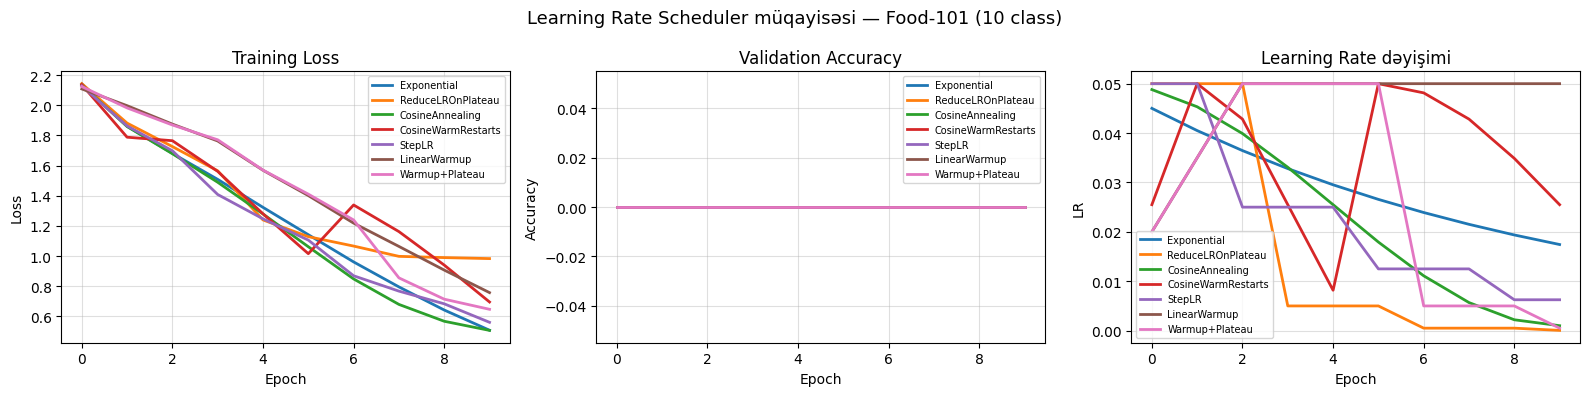

In [ ]:
# Bütün scheduler-lərin müqayisə qrafiki
all_results = {
    "Exponential":    (history_exp,  acc_exp),
    "ReduceLROnPlateau": (history_perf, acc_perf),
    "CosineAnnealing": (history_cos,  acc_cos),
    "CosineWarmRestarts": (history_cosr, acc_cosr),
    "StepLR":         (history_step, acc_step),
    "LinearWarmup":   (history_lin,  acc_lin),
    "Warmup+Plateau": (history_warm, acc_warm),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, (hist, acc) in all_results.items():
    axes[0].plot(hist["train_losses"],  label=name, linewidth=2)
    axes[1].plot(hist["valid_metrics"], label=name, linewidth=2)
    axes[2].plot(hist["learning_rates"], label=name, linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.4); axes[0].legend(fontsize=7)

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.4); axes[1].legend(fontsize=7)

axes[2].set_title("Learning Rate dəyişimi")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].grid(True, alpha=0.4); axes[2].legend(fontsize=7)
plt.suptitle("Learning Rate Scheduler müqayisəsi — Food-101 (10 class)", fontsize=13)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/scheduler_comparison.png", dpi=120)
plt.show()

In [ ]:
# Test Accuracy
print("\n" + "="*45)
print(f"{'Scheduler':<25} {'Test Accuracy':>13}")
print("="*45)
for name, (_, acc) in all_results.items():
    print(f"{name:<25} {acc:>13.4f}")
print("="*45)


Scheduler                 Test Accuracy
Exponential                      0.0000
ReduceLROnPlateau                0.0000
CosineAnnealing                  0.0000
CosineWarmRestarts               0.0000
StepLR                           0.0000
LinearWarmup                     0.0000
Warmup+Plateau                   0.0000


In [ ]:
# Mövcud bütün Pytorch scheduler-lərin siyahısı
print("\nPyTorch-da mövcud bütün LR Scheduler-lər:")
DOCS_URL = "https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler"
for name in sorted(dir(torch.optim.lr_scheduler)):
    scheduler_cls = getattr(torch.optim.lr_scheduler, name)
    if (not name.startswith("_")
            and isinstance(scheduler_cls, type)
            and issubclass(scheduler_cls, torch.optim.lr_scheduler.LRScheduler)):
        print(f"  • {DOCS_URL}.{name}.html")


PyTorch-da mövcud bütün LR Scheduler-lər:
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ChainedScheduler.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ConstantLR.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingWarmRestarts.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CyclicLR.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LRScheduler.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LambdaLR.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html
  • https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.MultiStepLR.html
  • https://pytorch.org/docs/stable/generated/torch.optim.

In [ ]:
# Handling overfitting through regularization

# L2 — weight_decay (optimizer vasitəsilə)
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, weight_decay=1e-4)
history = test_optimizer(torch.optim.SGD, {"lr": 0.05, "weight_decay": 1e-4})

Epoch 1: Loss 1.3490, Train Acc 0.0000, Val Acc 0.0000
Epoch 2: Loss 0.6394, Train Acc 0.0000, Val Acc 0.0000
Epoch 3: Loss 0.5472, Train Acc 0.0000, Val Acc 0.0000
Epoch 4: Loss 0.4727, Train Acc 0.0000, Val Acc 0.0000
Epoch 5: Loss 0.4206, Train Acc 0.0000, Val Acc 0.0000
Epoch 6: Loss 0.3441, Train Acc 0.0000, Val Acc 0.0000
Epoch 7: Loss 0.2631, Train Acc 0.0000, Val Acc 0.0000
Epoch 8: Loss 0.2541, Train Acc 0.0000, Val Acc 0.0000
Epoch 9: Loss 0.1806, Train Acc 0.0000, Val Acc 0.0000
Epoch 10: Loss 0.2579, Train Acc 0.0000, Val Acc 0.0000


In [ ]:
# L2 — manual hesablama
n_epochs = 3
train_loader = DataLoader(train_sched, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if "bias" not in name and "bn" not in name
]
for epoch in range(n_epochs):
    total_loss    = 0.0
    total_l2_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        main_loss = loss_fn(y_pred, y_batch)
        l2_loss = sum(p.pow(2.0).sum() for p in params_to_regularize)
        loss = main_loss + 1e-4 * l2_loss
        total_loss += loss.item()
        total_l2_loss += l2_loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch+1}/{n_epochs}"
          f" – l2 loss: {total_l2_loss / len(train_loader):.3f}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – l2 loss: 789.417 – loss: 2.213
Epoch 2/3 – l2 loss: 792.697 – loss: 1.953
Epoch 3/3 – l2 loss: 800.693 – loss: 1.787


In [ ]:
# L2 — param groups ilə (bias-a weight_decay=0)
n_epochs = 3
train_loader = DataLoader(train_sched, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()
model = build_model()
params_to_regularize = [
    param for name, param in model.named_parameters()
    if "bias" not in name and "bn" not in name
]
params_bias_and_bn = [
    param for name, param in model.named_parameters()
    if "bias" in name or "bn" in name
]
optimizer = torch.optim.SGD([
    {"params": params_to_regularize, "weight_decay": 1e-4},
    {"params": params_bias_and_bn,   "weight_decay": 0},
], lr=0.05)
for epoch in range(n_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch+1}/{n_epochs}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – loss: 2.137
Epoch 2/3 – loss: 1.866
Epoch 3/3 – loss: 1.707


In [ ]:
# L1 — manual hesablama
n_epochs = 3
train_loader = DataLoader(train_sched, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if "bias" not in name and "bn" not in name
]
for epoch in range(n_epochs):
    total_loss = 0.0
    total_l1_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        main_loss = loss_fn(y_pred, y_batch)
        l1_loss = sum(p.abs().sum() for p in params_to_regularize)
        loss = main_loss + 1e-4 * l1_loss
        total_loss += loss.item()
        total_l1_loss += l1_loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch+1}/{n_epochs}"
          f" – l1 loss: {total_l1_loss / len(train_loader):.3f}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – l1 loss: 35614.192 – loss: 5.698
Epoch 2/3 – l1 loss: 32159.257 – loss: 5.091
Epoch 3/3 – l1 loss: 29009.419 – loss: 4.631


In [ ]:
# Dropout
torch.manual_seed(42)
model = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(p=0.2), nn.Linear(3 * 64 * 64, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 10)
).to(device)

model.apply(use_he_init)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
# MC Dropout
model.eval()
for module in model.modules():
    if isinstance(module, nn.Dropout):
        module.train()
# Test setindən 3 nümunə götürürük
sample_loader = DataLoader(test_sched, batch_size=3, shuffle=True)
X_new, y_true = next(iter(sample_loader))
X_new = X_new.to(device)

torch.manual_seed(42)
with torch.no_grad():
    X_new_repeated = X_new.repeat_interleave(100, dim=0)
    y_logits_all = model(X_new_repeated).reshape(3, 100, 10)
    y_probas_all = torch.nn.functional.softmax(y_logits_all, dim=-1)
    y_probas = y_probas_all.mean(dim=1)

In [ ]:
y_probas.round(decimals=2)

tensor([[0.1300, 0.0600, 0.0400, 0.0900, 0.2400, 0.2100, 0.0300, 0.0600, 0.0400,
         0.0900],
        [0.1200, 0.0700, 0.0200, 0.1100, 0.0500, 0.3200, 0.0700, 0.0300, 0.0600,
         0.1400],
        [0.1200, 0.0400, 0.0600, 0.0800, 0.2500, 0.1900, 0.0500, 0.0700, 0.0400,
         0.0900]], device='cuda:0')

In [ ]:
y_std = y_probas_all.std(dim=1)
y_std.round(decimals=2)

tensor([[0.0700, 0.0400, 0.0300, 0.0600, 0.1300, 0.1100, 0.0300, 0.0500, 0.0300,
         0.0700],
        [0.1000, 0.0600, 0.0200, 0.1000, 0.0600, 0.1900, 0.0700, 0.0300, 0.0500,
         0.1000],
        [0.0400, 0.0200, 0.0200, 0.0400, 0.0900, 0.0700, 0.0200, 0.0400, 0.0200,
         0.0400]], device='cuda:0')

In [ ]:
class McDropout(nn.Dropout):
    def forward(self, input):
        return F.dropout(input, self.p, training=True)

In [ ]:
def mean_prediction(model, X, n_repeats):
    with torch.no_grad():
        X_repeated = X.repeat_interleave(n_repeats, dim=0)
        y_logits   = model(X_repeated)
        y_logits_r = y_logits.reshape(X.shape[0], n_repeats, *y_logits.shape[1:])
        y_probas_r = torch.nn.functional.softmax(y_logits_r, dim=-1)
    return y_probas_r.mean(dim=1)

In [ ]:
with torch.no_grad():
    y_mean_pred = mean_prediction(model, X_new, 100)

y_mean_pred.round(decimals=2)

tensor([[0.1200, 0.0600, 0.0400, 0.0900, 0.2500, 0.2400, 0.0300, 0.0600, 0.0300,
         0.0900],
        [0.1300, 0.0800, 0.0300, 0.1300, 0.0300, 0.2900, 0.0500, 0.0400, 0.0700,
         0.1600],
        [0.1100, 0.0500, 0.0600, 0.0900, 0.2500, 0.2000, 0.0400, 0.0800, 0.0400,
         0.0800]], device='cuda:0')

In [ ]:
# Max-Norm
def apply_max_norm(model, max_norm=2, epsilon=1e-8, dim=0):
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'bias' not in name and param.dim() >= 2:
                actual_norm = param.norm(p=2, dim=dim, keepdim=True)
                target_norm = torch.clamp(actual_norm, 0, max_norm)
                param.mul_(target_norm / (epsilon + actual_norm))

In [ ]:
torch.manual_seed(42)

n_epochs = 3
train_loader = DataLoader(train_sched, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
for epoch in range(n_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        apply_max_norm(model)
    print(f"Epoch {epoch+1}/{n_epochs}"
          f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – loss: 2.134
Epoch 2/3 – loss: 1.865
Epoch 3/3 – loss: 1.709
